# ローカル環境/短縮版
臨床に近い画像を利用するため、オフライン（ローカル）で実行するように改変しています。<br>
授業中のデモ用に単独で使用するため、あとでテキストにて学習可能な部分や不要と思われる部分は削除しています。<br>
[HN] で始まる Markdown ブロックを使用して、有用なコーディング ヒントを追加しました。これは  [Hints / Niigata-Univ H.Nishiyama version]を意味します。<br>
オリジナル: https://github.com/TMDU-AI/AI-yodosha<br>
新潟大学 H.Nishiyama が改訂しました。<br>

（オリジナル）# **5章　肺のX線画像を用いた画像分類にトライしよう**
# **5章　肺のX線画像のサンプルを用いた画像分類の例題にトライしよう**

***[HN] 注意：サンプルデータを使って構築したシステムの性能はサンプルデータに依存するように学習されます。***<br>
このため、外部から持ち込んだデータを分類しようとすると、誤った回答を出力する可能性が高いので、注意しましょう。<br>
また、読影に利用されるＸ線画像と比較し、解像度および諧調の不十分なものが使われています。<br>
このような問題（バイアス）が発生する例を、過去の深層学習システム関連のニュースから検索し、レポートとして提出してください。<br>
【参照】<a href="https://github.com/aujinen/AI-yodosha/blob/main/Chapter5/%E3%82%B5%E3%83%B3%E3%83%97%E3%83%AB%E3%83%87%E3%83%BC%E3%82%BF%E3%81%A8%E5%86%85%E6%8C%BF%E3%81%A8%E5%A4%96%E6%8C%BF%E3%81%A8%E9%A0%98%E5%9F%9F%E5%A4%96%E3%81%A8.pdf">サンプルデータと内挿と外挿と領域外と</a><br><br>
※ここで構築したシステムと内部パラメータを、診断目的のために利用することは、決してしないようにしましょう。<br>
【参照】薬機法<br>
・プログラムの医療機器該当性に関するガイドラインについて（令和５年３月31日一部改正）［2.0MB］<br>
https://www.mhlw.go.jp/content/11120000/001082227.pdf<br>
のp.16（PDFでp.17）の「改訂後」（左側）<br>
＝＝＝<br>
脚注 12<br>
<p style="background-color:yellow;">
「当該プログラムは、疾病の診断、治療又は予防に使用されること<br>
を目的としていない」又は「当該プログラムは医療機器ではない」<br>
旨の記載、表示があることをもって、当該プログラムが医療機器で<br>
はないことの根拠とはならない。そのような記載があっても、疾病<br>
の疑いを判断できるなどと医療機器との認識を与える広告・標ぼう<br>
をする製品は医療機器に該当する。<br>
</p>
＝＝＝

# 5-1　ローカル環境版：圧縮ファイルの解凍

コード5-0

In [1]:
#=# from google.colab import drive
#=# drive.mount('/content/drive')
%pwd #++

'c:\\Users\\BN\\Python\\GitHub-Clone\\AI-yodosha\\Chapter5'

コード5-1-1　images_TMDU.zipの解凍

### #++ added new cell ++#
#### Windows用

In [2]:
! powershell -command "if (-Not (Test-Path -Path "content/images")) {Expand-Archive images_TMDU.zip -DestinationPath content}"

（オリジナル）# 5-3　肺のX線画像の分類モデルを作成してみよう
# 5-3　肺のX線画像のサンプルにて分類モデルを作成してみよう

**STEP1　肺のX線画像ファイルのリスト作成**

コード5-3-1　ファイル名のリストを作成

In [3]:
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

In [4]:
import os
list_healthy = [
    #=# i for i in os.listdir('/content/images/COVID-NORMAL/healthy')
    i for i in os.listdir('content/images/COVID-NORMAL/healthy') #++
    if not i.startswith('.')]
list_covid19 = [
    #=# i for i in os.listdir('/content/images/COVID-NORMAL/covid19')
    i for i in os.listdir('content/images/COVID-NORMAL/covid19') #++
    if not i.startswith('.')]
print(len(list_healthy))
print(len(list_covid19))

116
116


コード5-3-5　os.listdir()の確認１

In [5]:
import os
#=# os.listdir('/content/images/COVID-NORMAL')
os.listdir('content/images/COVID-NORMAL') #++

['covid19', 'healthy']

**STEP2　画像ファイル数の集計と変数の作成**

コード5-3-7　画像ファイル数の集計

In [6]:
num_healthy = len(list_healthy)
num_covid19 = len(list_covid19)
num_all = num_healthy + num_covid19
print(num_all)

232


コード5-3-8　画像データ格納用NumPy配列の作成

In [7]:
import numpy as np
images_temp = np.zeros((num_all, 64, 64, 1), dtype=float)
labels_temp = np.zeros((num_all, 1), dtype=int)
print(images_temp.shape)
print(labels_temp.shape)

(232, 64, 64, 1)
(232, 1)


コード5-3-9　画像データ格納用NumPy配列の値の確認

In [8]:
#print(labels_temp)
#print(images_temp[0])

（オリジナル）**STEP3　健康な肺のX線画像の読み込み**<br>
**STEP3　健康な肺のサンプルのX線画像[*]の読み込み**<br>
*: 読影に利用されるＸ線画像と比較し、解像度および諧調の不十分なものが使われています。

コード5-3-10　画像の読み込み（list_healthy）



In [9]:
#=# path_healthy = '/content/images/COVID-NORMAL/healthy'
path_healthy = 'content/images/COVID-NORMAL/healthy' #++
for i in range(num_healthy):
  file = f'{path_healthy}/{list_healthy[i]}'
  file_img = load_img(
      file, color_mode='grayscale', target_size=(64, 64),
      interpolation='lanczos')
  images_temp[i] = img_to_array(file_img) / 255
  labels_temp[i] = 0

（オリジナル）**STEP4　肺炎のX線画像の読み込み**<br>
**STEP4　肺炎のサンプルのX線画像[*]の読み込み**<br>
*: 読影に利用されるＸ線画像と比較し、解像度および諧調の不十分なものが使われています。

コード5-3-13　画像の読み込み（list_covid19）

In [10]:
#=# path_covid19 = '/content/images/COVID-NORMAL/covid19'
path_covid19 = 'content/images/COVID-NORMAL/covid19' #++
for i in range(num_covid19):
  file = f'{path_covid19}/{list_covid19[i]}'
  file_img = load_img(
      file, color_mode='grayscale', target_size=(64, 64),
      interpolation='lanczos')
  images_temp[i + num_healthy] = img_to_array(file_img) / 255
  labels_temp[i + num_healthy] = 1

**STEP5　X線画像のシャッフル**

コード5-3-15　0から231までの数字の配列を作成

In [11]:
num_list = np.arange(num_all)
#print(num_list)

コード5-3-16　NumPy配列をシャッフルする

In [12]:
np.random.seed(111)
np.random.shuffle(num_list)
#print(num_list)

コード5-3-17　images_tempとlabels_tempの配列をシャッフルする

In [13]:
print(labels_temp[0:10])
x_train = images_temp[num_list]
y_train = labels_temp[num_list]
#print(y_train[0:10])
#print(x_train.shape)
#print(y_train.shape)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


コード5-3-18　NumPy配列の要素を並べ替える

In [14]:
array1 = np.array([10, 20, 30, 40, 50])
print(array1)
order = [3, 2, 0, 4, 1]
array2 = array1[order]
print(array2)

[10 20 30 40 50]
[40 30 10 50 20]


**STEP6　深層学習モデルの作成**

コード5-3-19　深層学習モデルの作成

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

model = Sequential()
model.add(Flatten(input_shape=(64, 64, 1))) # 配列を1次元に変換
model.add(Dense(512, activation='relu'))  # 中間層1層目を作成
model.add(Dense(256, activation='relu'))  # 中間層2層目を作成
model.add(Dense(128, activation='relu'))  # 中間層3層目を作成
model.add(Dense(1, activation='sigmoid')) # 出力層を作成
model.compile(
    loss='binary_crossentropy', optimizer='Adam',
    metrics=['accuracy']) # 学習方法の設定
model.summary()

c:\Users\BN\p11tf\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,262,017 (8.63 MB)

 Trainable params: 2,262,017 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

コード5-3-20　学習の実施

In [16]:
result = model.fit(
    x_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5207 - loss: 1.0792 - val_accuracy: 0.4681 - val_loss: 0.7165
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4830 - loss: 0.7078 - val_accuracy: 0.5745 - val_loss: 0.7449
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6805 - loss: 0.5624 - val_accuracy: 0.5745 - val_loss: 0.8422
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6153 - loss: 0.6973 - val_accuracy: 0.5745 - val_loss: 0.9792
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6612 - loss: 0.6900 - val_accuracy: 0.6170 - val_loss: 0.7281
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7921 - loss: 0.5105 - val_accuracy: 0.6170 - val_loss: 0.6576
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7774 - loss: 0.5119 - val_accuracy: 0.5106 - val_loss: 0.7341
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6731 - loss: 0.6045 - val_accuracy: 0.7021 - val_loss:

コード5-3-21　学習過程の図示

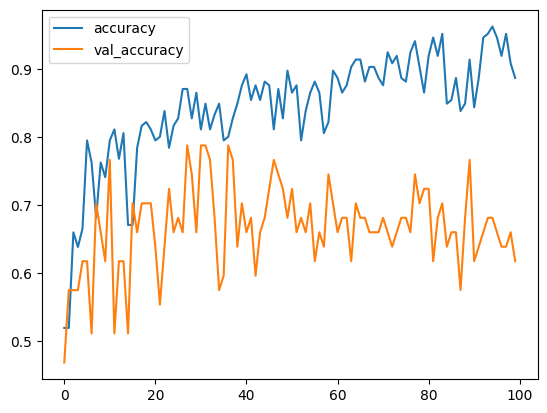

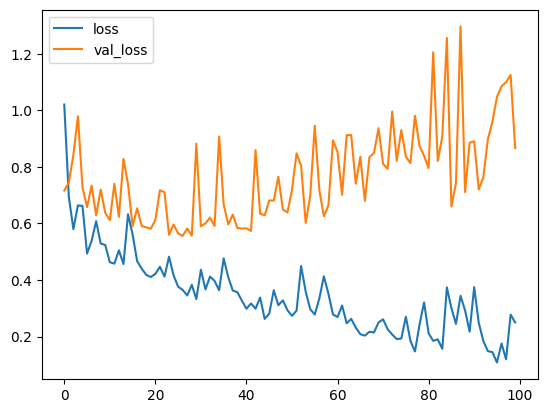

In [17]:
import matplotlib.pyplot as plt
plt.plot(result.history['accuracy'], label='accuracy')
plt.plot(result.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()
plt.plot(result.history['loss'], label='loss')
plt.plot(result.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

コード5-3-22　Dropoutを加えて過学習を防ぐ

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout # Dropout関数を追加

model = Sequential()
model.add(Flatten(input_shape=(64, 64, 1)))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Dropoutの層を追加
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5)) # Dropoutの層を追加
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
model.summary()
result = model.fit(
    x_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,262,017 (8.63 MB)

 Trainable params: 2,262,017 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6044 - loss: 1.1591 - val_accuracy: 0.5319 - val_loss: 2.4888
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4720 - loss: 1.7826 - val_accuracy: 0.4681 - val_loss: 0.8097
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5438 - loss: 1.1488 - val_accuracy: 0.6596 - val_loss: 0.6747
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5172 - loss: 0.9641 - val_accuracy: 0.4681 - val_loss: 0.7941
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5321 - loss: 0.8842 - val_accuracy: 0.4681 - val_loss: 0.7182
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4864 - loss: 0.9297 - val_accuracy: 0.4681 - val_loss: 0.7962
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5474 - loss: 0.9558 - val_accuracy: 0.5745 - val_loss: 0.6841
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5471 - loss: 0.8573 - val_accuracy: 0.4681 - val_loss:

コード5-3-23　Dropoutを加えた学習過程の図示

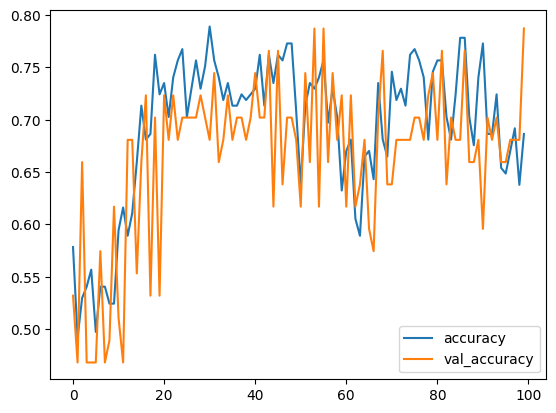

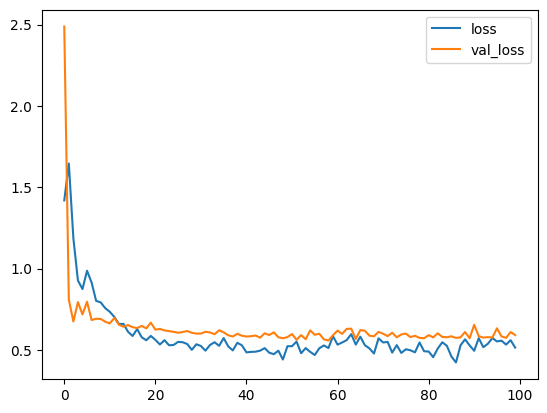

In [19]:
import matplotlib.pyplot as plt
plt.plot(result.history['accuracy'], label='accuracy')
plt.plot(result.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()
plt.plot(result.history['loss'], label='loss')
plt.plot(result.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# 5-4　未知のデータが肺炎かどうかを予測
[HN]注意：「肺炎かどうかを予測」とありますが、信頼性は学習データのバイアスに依存しているので注意して下さい。<br>
また、汎化性能に関連する「内挿領域なのか、外挿領域なのか」あるいは「カテゴリー範囲外（対象領域外）」かといった問題も大きく関わってきます。<br>
例えば、冒頭に扱った「test.jpg」から、1024x1024の領域を抜き出し、8bit画像にして保存した「test-01.jpg」と「test-02.jpg」を入力したとき、どのように回答するのか？といったことを確認してみるのも良いでしょう。<br>

コード5-4-1　新たな画像での分類

In [ ]:
img1 = img_to_array(load_img(
    #=# '/content/images/covid.jpg',
    'content/images/covid.jpg', #++
    color_mode='grayscale', target_size=(64, 64))) / 255
img2 = img_to_array(load_img(
    #=# '/content/images/NORMAL.jpg',
    'content/images/NORMAL.jpg', #++
    color_mode='grayscale', target_size=(64, 64))) / 255


In [21]:
check = np.zeros((2, 64, 64, 1))
check[0] = img1
check[1] = img2
prob = model.predict(check)
print(prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.9416887 ]
 [0.07155346]]


#### [HN]テスト画像表示<br>
オリジナルが1024x1024であるが64x64での学習・評価なので注意

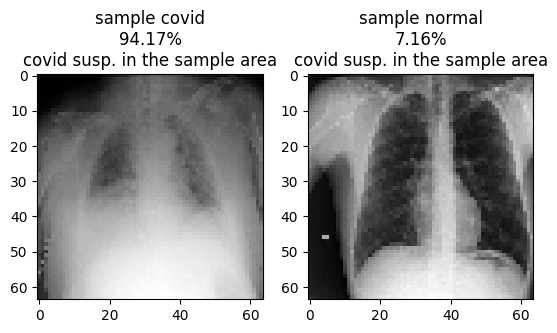

In [22]:
plt.subplot(1,2,1)
plt.title("sample covid\n" + f"{prob[0][0]*100:.2f}%"
           + "\ncovid susp. in the sample area")
plt.imshow(img1,'gray')
plt.subplot(1,2,2)
plt.title("sample normal\n" + f"{prob[1][0]*100:.2f}%"
           + "\ncovid susp. in the sample area")
plt.imshow(img2,'gray')
plt.show()

### [HN]補遺：外挿領域やカテゴリー範囲外（対象領域外）の画像の場合
冒頭に扱った「test.jpg」から、1024x1024の領域を抜き出し、8bit画像にして保存した「test-01.jpg」と「test-02.jpg」を入力したとき、どのように回答するのか？<br>
オリジナルが1024x1024であるが64x64での学習・評価なので注意

In [23]:
img1 = img_to_array(load_img(
    'test-01.jpg', 
    color_mode='grayscale', target_size=(64, 64))) / 255
img2 = img_to_array(load_img(
    'test-02.jpg',
    color_mode='grayscale', target_size=(64, 64))) / 255

In [24]:
check = np.zeros((2, 64, 64, 1))
check[0] = img1
check[1] = img2
prob = model.predict(check)
print(prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[0.8609451 ]
 [0.14160731]]


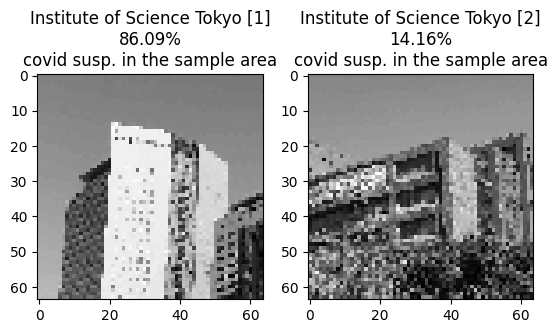

In [25]:
plt.subplot(1,2,1)
plt.title("Institute of Science Tokyo [1]\n" + f"{prob[0][0]*100:.2f}%"
           + "\ncovid susp. in the sample area")
plt.imshow(img1,'gray')
plt.subplot(1,2,2)
plt.title("Institute of Science Tokyo [2]\n" + f"{prob[1][0]*100:.2f}%"
           + "\ncovid susp. in the sample area")
plt.imshow(img2,'gray')
plt.show()